In [38]:
import os
from PIL import Image
import polars as pl
from sklearn.cluster import DBSCAN
import numpy as np

BASEPATH = "/Users/affahrizain/projects/phd-research/dataset/geotir"

In [13]:
df = pl.read_csv(os.path.join(BASEPATH, "jp_gldv_mp16_merged_saliency.csv"))
df = df.filter((pl.col("dataset") == "gldv2-full") & (pl.col("country_code") == "JP"))
df

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str
20,"""4e7bf3e2529ae499""",31.564831,130.560186,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kagoshima-shi""",0.094482,0.15,false,"""sports venue""","""gldv2-full""","""train""","""The image displays a large, op…","""sports venue""","""The main architectural structu…",0.75,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
6,"""8d6d459d74c62469""",33.592194,130.40675,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fukuoka-shi""",0.480467,0.15,true,"""church""","""gldv2-full""","""train""","""The image displays a large, re…","""dam""","""The main architectural structu…",0.75,"""This is a real photograph of a…",true,1.0,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,1.0,null,null
17,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""shinto shrine""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto shrine""","""The structure occupies approxi…",0.4,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
18,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""dam""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto shrine""","""The structure occupies approxi…",0.4,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
37,"""cf724c3632280892""",34.673972,133.299944,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fuchucho""",0.181179,0.15,true,null,"""gldv2-full""","""train""","""The image shows a large, multi…","""city""","""The main architectural structu…",0.35,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
108598,"""648381cee2f625fb""",33.172943,131.598277,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Oita""",0.359588,0.15,true,null,"""gldv2-full""","""index""","""The image displays a large, mu…","""garden""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A modern architectural garden …",null
108622,"""61692415e085e617""",35.248167,139.042667,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hakone""",0.0,0.15,false,null,"""gldv2-full""","""index""","""The image displays a large, fl…","""square""","""The main architectural structu…",0.85,"""This image is a real photograp…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A large, flat, reddish-brown p…",null
108504,"""0cb41d3ad76acb97""",34.462417,135.433347,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Izumi""",0.45747,0.15,true,"""bridge""","""gldv2-full""","""index""","""The image displays a series of…","""non_landmark""","""The image shows a seascape wit…",0.0,"""The image shows a seascape wit…",false,0.0,"""The image shows a seascape wit…","""outdoor""","""other""",false,0.0,"""A seascape featuring dark rock…",null


In [14]:
# df.group_by("landmark_category").agg(pl.len().alias("total")).sort("landmark_category", descending=True).write_csv("./landmark-category.csv")
tower_df = df.filter(pl.col("landmark_category").is_in(["tower", "skyscraper", "lighthouse"]))
tower_df.head()

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str
38,"""c5d6b299b96c27a3""",32.695556,128.840806,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fukuecho""",0.0,0.15,false,"""city""","""gldv2-full""","""train""","""The image shows a tall, slende…","""tower""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
338,"""cc1a340a56316437""",35.330941,136.671186,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Ogaki""",0.477642,0.15,true,null,"""gldv2-full""","""train""","""The image displays a tall, sle…","""tower""","""The structure occupies a signi…",0.75,"""This is a real photograph of a…",true,1.0,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,1.0,null,null
368,"""5136d920acf83376""",34.35,133.938889,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Takamatsu-shi""",0.158591,0.15,true,"""church""","""gldv2-full""","""train""","""The image displays two tall, l…","""tower""","""The main architectural structu…",0.95,"""This is a real photograph of a…",true,1.0,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,1.0,null,null
407,"""2699e1514f7fa380""",34.225,135.171417,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Wakayama-shi""",0.630432,0.15,true,null,"""gldv2-full""","""train""","""The image displays a series of…","""tower""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,1.0,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,1.0,null,null
447,"""03e8f3413e891141""",40.633583,140.577667,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kuroishi""",0.19186,0.15,true,null,"""gldv2-full""","""train""","""The image displays a tall, lig…","""tower""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null


In [16]:
R = 6371.0
eps_km = 0.1
eps_rad = eps_km / R

coords = tower_df[["latitude", "longitude"]].to_numpy()
coords = np.radians(coords)
dbscan = DBSCAN(eps=eps_rad, metric="haversine")
labels = dbscan.fit_predict(coords)
tower_df = tower_df.with_columns(pl.Series("cluster_id", labels))
print(f"Total cluster: {tower_df['cluster_id'].n_unique()}")

Total cluster: 29


In [17]:
import plotly.express as px

fig = px.scatter_map(
    # tower_df.filter(pl.col("cluster_id") > -1).to_pandas(),
    tower_df.to_pandas(),
    lat="latitude",
    lon="longitude",
    zoom=12,
    center={"lat": 35.6895, "lon": 139.7517},
    # color="cluster_id",
)

fig.update_layout(height=500, width=800, margin=dict(l=10, r=10, t=10, b=10))

fig.show()

In [35]:
tower_df.filter(pl.col("city") == "Tokyo").filter((pl.col("latitude") >= 35.657) & (pl.col("longitude") >= 139.7)).sort("latitude")

# .filter((pl.col("latitude") >= 35.658) & (pl.col("longitude") >= 139.7))

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption,cluster_id
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str,i64
2166,"""6c0266ac9bd0340b""",35.657479,139.748376,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.063696,0.15,false,"""temple""","""gldv2-full""","""train""","""The image displays a tall, sle…","""tower""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null,-1
20614,"""f2d46fac044a3eb6""",35.657479,139.748376,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.843738,0.15,true,"""temple""","""gldv2-full""","""train""","""The image clearly shows the To…","""tower""","""The Tokyo Tower is the primary…",0.85,"""This is a real photograph of t…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null,-1
3176,"""17d34b0bdfe93caf""",35.658611,139.745556,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.0,0.15,false,"""temple""","""gldv2-full""","""train""","""The image displays a framed po…","""tower""","""The image shows a framed poste…",0.85,"""The image is a photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null,7
3175,"""17d34b0bdfe93caf""",35.658611,139.745556,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.0,0.15,false,"""tower""","""gldv2-full""","""train""","""The image displays a framed po…","""tower""","""The image shows a framed poste…",0.3,"""The image is a photograph of t…",true,0.95,"""The image is a photograph take…","""outdoor""","""exterior_facing_landmark""",true,0.95,null,null,7
5421,"""2334a399f16c16ae""",35.658611,139.745556,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.06811,0.15,false,"""tower""","""gldv2-full""","""train""","""The image shows a tall, lattic…","""tower""","""The tower occupies a significa…",0.75,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
106220,"""b17e08b263958dc4""",35.714167,139.726667,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.231266,0.15,true,"""parks""","""gldv2-full""","""index""","""The image displays a tall, sle…","""tower""","""The main architectural structu…",0.95,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A tall, illuminated cylindrica…",null,-1
86199,"""ccb97efdb159d0e7""",35.715744,139.793162,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.0,0.15,false,null,"""gldv2-full""","""train""","""The image displays a lighthous…","""tower""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A lighthouse stands tall on a …",null,-1
36197,"""6c972c4625218905""",35.722222,139.719444,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Tokyo""",0.362592,0.15,true,null,"""gldv2-full""","""train""","""The image displays a tall, rec…","""tower""","""The main architectural structu…",0.6,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null,-1


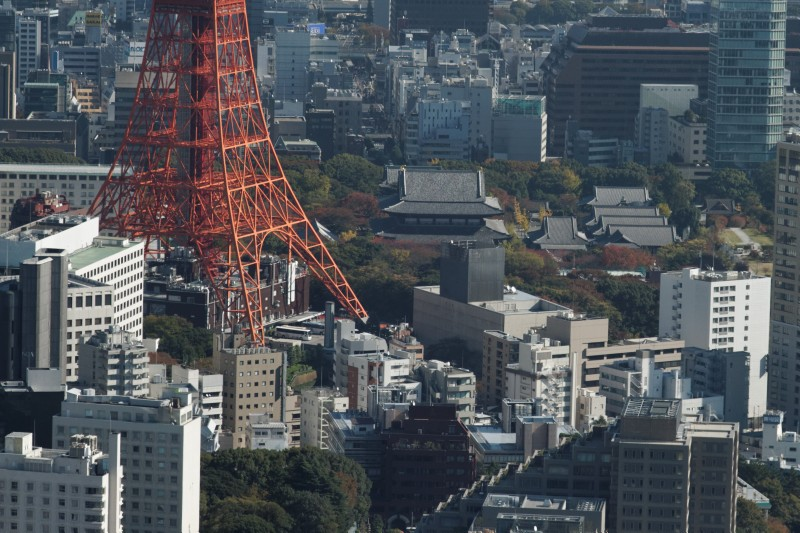

In [40]:
Image.open(os.path.join(BASEPATH, "gldv2-full/train/f2d46fac044a3eb6.jpg"))

In [37]:
for item in os.listdir(os.path.join(BASEPATH, "gldv2-full/train/")):
    print(item)
    break

FileNotFoundError: [Errno 2] No such file or directory: '~/projects/phd-research/dataset/geotir/gldv2-full/train/'

In [12]:
df.filter((pl.col("dataset") == "gldv2-full") & (pl.col("country_code") == "JP"))

row_idx,id,latitude,longitude,country_code,country,region,subregion,city,ratio,threshold,is_landmark,category,dataset,src,category_reasoning,landmark_category,visual_reasoning,landmark_coverage,semantic_reasoning,is_semantically_salient,semantic_confidence,structural_reasoning,scene_type,viewpoint,is_structurally_salient,structural_confidence,error,caption
i64,str,f64,f64,str,str,str,str,str,f64,f64,bool,str,str,str,str,str,str,f64,str,bool,f64,str,str,str,bool,f64,str,str
20,"""4e7bf3e2529ae499""",31.564831,130.560186,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Kagoshima-shi""",0.094482,0.15,false,"""sports venue""","""gldv2-full""","""train""","""The image displays a large, op…","""sports venue""","""The main architectural structu…",0.75,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,0.99,null,null
6,"""8d6d459d74c62469""",33.592194,130.40675,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fukuoka-shi""",0.480467,0.15,true,"""church""","""gldv2-full""","""train""","""The image displays a large, re…","""dam""","""The main architectural structu…",0.75,"""This is a real photograph of a…",true,1.0,"""The photograph is taken from o…","""outdoor""","""exterior_facing_landmark""",true,1.0,null,null
17,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""shinto shrine""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto shrine""","""The structure occupies approxi…",0.4,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
18,"""f696b4b0f673944d""",32.213333,130.752778,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hitoyoshi""",0.510129,0.15,true,"""dam""","""gldv2-full""","""train""","""The image displays a tradition…","""shinto shrine""","""The structure occupies approxi…",0.4,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
37,"""cf724c3632280892""",34.673972,133.299944,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Fuchucho""",0.181179,0.15,true,null,"""gldv2-full""","""train""","""The image shows a large, multi…","""city""","""The main architectural structu…",0.35,"""This is a real photograph of a…",true,0.95,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.98,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
108598,"""648381cee2f625fb""",33.172943,131.598277,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Oita""",0.359588,0.15,true,null,"""gldv2-full""","""index""","""The image displays a large, mu…","""garden""","""The main architectural structu…",0.85,"""This is a real photograph of a…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A modern architectural garden …",null
108622,"""61692415e085e617""",35.248167,139.042667,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Hakone""",0.0,0.15,false,null,"""gldv2-full""","""index""","""The image displays a large, fl…","""square""","""The main architectural structu…",0.85,"""This image is a real photograp…",true,0.98,"""The photograph is taken from a…","""outdoor""","""exterior_facing_landmark""",true,0.99,"""A large, flat, reddish-brown p…",null
108504,"""0cb41d3ad76acb97""",34.462417,135.433347,"""JP""","""Japan""","""Asia""","""Eastern Asia""","""Izumi""",0.45747,0.15,true,"""bridge""","""gldv2-full""","""index""","""The image displays a series of…","""non_landmark""","""The image shows a seascape wit…",0.0,"""The image shows a seascape wit…",false,0.0,"""The image shows a seascape wit…","""outdoor""","""other""",false,0.0,"""A seascape featuring dark rock…",null
